# CCP Assignment: Robust Chest X-ray Classification (Normal vs Disease)

This notebook implements an end-to-end, real-world robust deep learning pipeline for chest X-ray binary classification.

It addresses:
- Heterogeneous multi-source data
- Class imbalance
- Label noise
- Limited sample size
- Cross-domain generalization and clinical trade-offs

Expected dataset (RSNA-style):
- `dataset/stage_2_train_images/*.dcm`
- `dataset/stage_2_test_images/*.dcm`
- `dataset/stage_2_train_labels.csv`
- `dataset/stage_2_detailed_class_info.csv`


In [2]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')
print(path)

100%|██████████| 3.66G/3.66G [00:23<00:00, 166MB/s]

Extracting files...


/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge


In [3]:
# Colab/local setup (compatible with newer Python versions)
!pip -q install pydicom albumentations timm scikit-learn seaborn torchmetrics netcal


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 18.5 MB/s eta 0:00:00


In [4]:
## https://www.kaggle.com/lostbox/rsna-classification-87-6-best-accuracy-p-cda585 was used as a guide in the transformation process

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pydicom import dcmread
from tqdm import tqdm
from torch.utils import data
from sklearn.model_selection import train_test_split

In [5]:
label_data = pd.read_csv('/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv')
columns = ['patientId', 'Target']

label_data = label_data.filter(columns)
label_data.head(5)

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0
4,00436515-870c-4b36-a041-de91049b9ab4,1


In [6]:
train_labels, val_labels = train_test_split(label_data.values, test_size=0.1)
print(train_labels.shape)
print(val_labels.shape)

(27204, 2)
(3023, 2)


In [7]:
TRAIN_LABELS = os.path.join(path, 'stage_2_train_labels.csv')
DETAIL_CSV = os.path.join(path, 'stage_2_detailed_class_info.csv')

labels_df = pd.read_csv(TRAIN_LABELS)
detailed_df = pd.read_csv(DETAIL_CSV)

print("Labels rows:", len(labels_df))
print("Unique patients:", labels_df["patientId"].nunique())
print("\nTarget distribution:")
print(labels_df["Target"].value_counts())
print("\nDetailed class distribution:")
print(detailed_df["class"].value_counts())

# Build patient-level table for binary classification
patient_df = labels_df.groupby("patientId", as_index=False)["Target"].max()
patient_df["label_name"] = patient_df["Target"].map({0: "Normal", 1: "Disease"})
print("\nPatient-level class balance:")
print(patient_df["label_name"].value_counts())

Labels rows: 30227
Unique patients: 26684

Target distribution:
Target
0    20672
1     9555
Name: count, dtype: int64

Detailed class distribution:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Patient-level class balance:
label_name
Normal     20672
Disease     6012
Name: count, dtype: int64


/tmp/ipykernel_4221/961161700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Target", data=labels_df, ax=ax[0], palette="Set2")
/tmp/ipykernel_4221/961161700.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Normal (0)", "Disease (1)"])
/tmp/ipykernel_4221/961161700.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label_name", data=patient_df, ax=ax[1], palette="Set1")


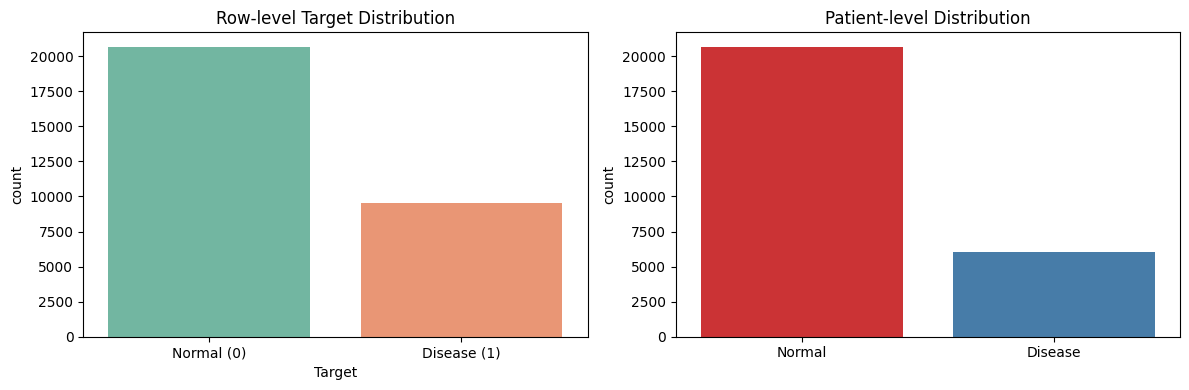

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Target", data=labels_df, ax=ax[0], palette="Set2")
ax[0].set_title("Row-level Target Distribution")
ax[0].set_xticklabels(["Normal (0)", "Disease (1)"])

sns.countplot(x="label_name", data=patient_df, ax=ax[1], palette="Set1")
ax[1].set_title("Patient-level Distribution")
ax[1].set_xlabel("")
plt.tight_layout()
plt.show()


In [9]:
train_f = '/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images'
test_f = '/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge/stage_2_test_images'

train_paths = [os.path.join(train_f, image[0]) for image in train_labels]
val_paths = [os.path.join(train_f, image[0]) for image in val_labels]


In [10]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),
    transforms.ToTensor()])

In [11]:
class Dataset(data.Dataset):

    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        image = dcmread(f'{self.paths[index]}.dcm')
        image = image.pixel_array
        image = image / 255.0

        image = (255*image).clip(0, 255).astype(np.uint8)
        image = Image.fromarray(image).convert('RGB')

        label = self.labels[index][1]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

    def __len__(self):

        return len(self.paths)

Tensor:tensor([[[0.7216, 0.6980, 0.6745,  ..., 0.7843, 0.8039, 0.7843],
         [0.6196, 0.5490, 0.4980,  ..., 0.7255, 0.7451, 0.7294],
         [0.3608, 0.2314, 0.1490,  ..., 0.6510, 0.6706, 0.6627],
         ...,
         [0.0392, 0.0353, 0.0353,  ..., 0.0000, 0.0000, 0.0118],
         [0.0353, 0.0353, 0.0392,  ..., 0.0000, 0.0000, 0.0118],
         [0.0392, 0.0392, 0.0392,  ..., 0.0000, 0.0000, 0.0118]],

        [[0.7216, 0.6980, 0.6745,  ..., 0.7843, 0.8039, 0.7843],
         [0.6196, 0.5490, 0.4980,  ..., 0.7255, 0.7451, 0.7294],
         [0.3608, 0.2314, 0.1490,  ..., 0.6510, 0.6706, 0.6627],
         ...,
         [0.0392, 0.0353, 0.0353,  ..., 0.0000, 0.0000, 0.0118],
         [0.0353, 0.0353, 0.0392,  ..., 0.0000, 0.0000, 0.0118],
         [0.0392, 0.0392, 0.0392,  ..., 0.0000, 0.0000, 0.0118]],

        [[0.7216, 0.6980, 0.6745,  ..., 0.7843, 0.8039, 0.7843],
         [0.6196, 0.5490, 0.4980,  ..., 0.7255, 0.7451, 0.7294],
         [0.3608, 0.2314, 0.1490,  ..., 0.6510, 0.6

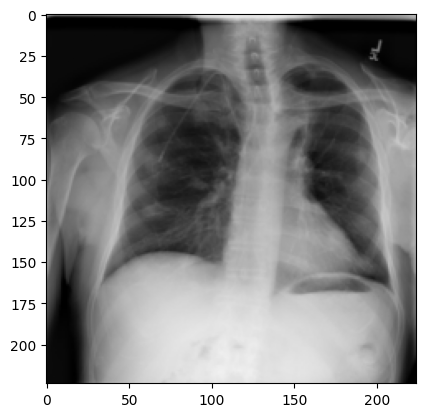

In [12]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
image = iter(train_dataset)
img, label = next(image)
print(f'Tensor:{img}, Label:{label}')
img = np.transpose(img, (1, 2, 0))
plt.imshow(img)

In [13]:
img.shape

torch.Size([224, 224, 3])

In [14]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
val_dataset = Dataset(val_paths, val_labels, transform=transform)
train_loader = data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=128, shuffle=False)

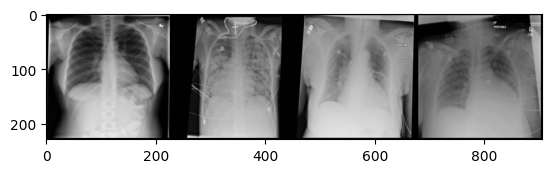

In [15]:
batch = iter(train_loader)
images, labels = next(batch)

image_grid = torchvision.utils.make_grid(images[:4])
image_np = image_grid.numpy()
img = np.transpose(image_np, (1, 2, 0))
plt.imshow(img)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
model = torchvision.models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model.fc = nn.Linear(num_ftrs, 2)

model.to(device)

criterion = nn.CrossEntropyLoss()
criterion2 = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 70.8MB/s]


In [18]:
print(model) # ResNet18 Model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
num_epochs = 15
# Train the model
total_step = len(train_loader)

train_loss, validation_loss = [], []
train_acc, validation_acc = [], []

train_preds = torch.tensor([]).to(device)
train_labels_tensor = torch.tensor([]).to(device)

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.
    correct, total = 0, 0
    steps = 0
    # Training step
    for i, (images, labels) in tqdm(enumerate(train_loader)):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        print("Loss: " + str(loss.item()))

        steps += 1
        running_loss += loss.item()

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # get accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_preds = torch.cat((train_preds, predicted), dim=0)
        train_labels_tensor = torch.cat((train_labels_tensor, labels), dim=0)

        if (i+1) % 2000 == 0:

            print("Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}"
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

    train_loss.append(running_loss/len(train_loader))
    train_acc.append(correct/total)

    print(f'Epoch: {epoch + 1},  Training Loss: {running_loss/len(train_loader):.4f}, Training Accuracy: {100*correct/total: .2f}%')

    # Validation step
    model.eval()
    running_loss = 0.
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            predictions = model(images)
            loss = criterion(predictions, labels)
            running_loss += loss.item()
            _, predicted = torch.max(predictions, 1)
            total += labels.size(0)
            correct += (labels == predicted).sum()
    validation_loss.append(running_loss/len(val_loader))
    validation_acc.append(correct/total)

    print(f'Epoch: {epoch+1}/{num_epochs}, Validation Loss : {running_loss / len(val_loader)} Val_Acc: {100*correct/total}')

0it [00:00, ?it/s]

Loss: 1.3867977857589722


1it [00:11, 11.03s/it]

Loss: 0.9523136615753174


2it [00:15,  7.20s/it]

...

Loss: 0.07763685286045074


213it [10:44,  3.03s/it]


Loss: 0.03204534947872162
Epoch: 15,  Training Loss: 0.0426, Training Accuracy:  98.96%


100%|██████████| 24/24 [01:05<00:00,  2.72s/it]

Epoch: 15/15, Validation Loss : 0.5571789033710957 Val_Acc: 85.5110855102539


In [20]:
train_loss

[0.45998370115745796,
 0.39058089270278323,
 0.3714411756802053,
 0.34984573106250855,
 0.33075519787593627,
 0.3091569749262411,
 0.2853326719831413,
 0.2554572345645215,
 0.22237492831939823,
 0.18611847228007697,
 0.14846660077851703,
 0.11620169162680286,
 0.08343286555207952,
 0.06130828089277509,
 0.04256424386963738]

In [21]:
train_acc

[0.779811792383473,
 0.8225260991030731,
 0.8316424055285987,
 0.8417879723570063,
 0.8524481693868549,
 0.8661226290251434,
 0.8794294956624026,
 0.8952727540067638,
 0.9143140714600794,
 0.9305249228054698,
 0.9479488310542568,
 0.9622114394941921,
 0.9756653433318629,
 0.9833847963534774,
 0.989560358770769]

In [22]:
validation_loss

[0.4092982200284799,
 0.3944745833675067,
 0.38773158316810924,
 0.3878844976425171,
 0.38107966259121895,
 0.3999446804324786,
 0.37972024952371913,
 0.38788288335005444,
 0.4327441987891992,
 0.4165770610173543,
 0.4384533440073331,
 0.45726178586483,
 0.4750870242714882,
 0.5274021029472351,
 0.5571789033710957]

In [23]:
validation_acc

[tensor(0.8108, device='cuda:0'),
 tensor(0.8187, device='cuda:0'),
 tensor(0.8187, device='cuda:0'),
 tensor(0.8250, device='cuda:0'),
 tensor(0.8267, device='cuda:0'),
 tensor(0.8081, device='cuda:0'),
 tensor(0.8290, device='cuda:0'),
 tensor(0.8333, device='cuda:0'),
 tensor(0.8204, device='cuda:0'),
 tensor(0.8369, device='cuda:0'),
 tensor(0.8320, device='cuda:0'),
 tensor(0.8382, device='cuda:0'),
 tensor(0.8611, device='cuda:0'),
 tensor(0.8422, device='cuda:0'),
 tensor(0.8551, device='cuda:0')]

In [24]:
model.eval()

correct = 0
total = 0
val_preds = torch.tensor([]).to(device)
for images, labels in tqdm(val_loader):
    images = images.to(device)
    labels = labels.to(device)
    predictions = model(images)
    _, predicted = torch.max(predictions, 1)
    val_preds = torch.cat((val_preds, predicted),dim=0)
    total += labels.size(0)
    correct += (labels == predicted).sum()
print(f'Val_Acc: {100*correct/total}')

100%|██████████| 24/24 [01:06<00:00,  2.78s/it]

Val_Acc: 85.3456802368164


In [25]:
val_preds.shape

torch.Size([3023])

In [26]:
pip install git+git://github.com/raghakot/keras-vis.git --upgrade --no-deps

  Cloning git://github.com/raghakot/keras-vis.git to /tmp/pip-req-build-346o5qs7
  Running command git clone --filter=blob:none --quiet git://github.com/raghakot/keras-vis.git /tmp/pip-req-build-346o5qs7
  fatal: unable to connect to github.com:
  github.com[0: 140.82.116.3]: errno=Connection timed out

  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet git://github.com/raghakot/keras-vis.git /tmp/pip-req-build-346o5qs7 did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet git://github.com/raghakot/keras-vis.git /tmp/pip-req-build-346o5qs7 did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [27]:
def print_saliency(i):
    image_test = images[i]
    # from: https://towardsdatascience.com/saliency-map-using-pytorch-68270fe45e80
    image_test = image_test.reshape(1, 3, 224, 224)
    image_test = image_test.to(device)
    image_test.requires_grad_()

    # Retrieve output from the image
    output = model(image_test)

    # Catch the output
    output_idx = output.argmax()
    output_max = output[0, output_idx]

    # Do backpropagation to get the derivative of the output based on the image
    output_max.backward()

    # Retireve the saliency map and also pick the maximum value from channels on each pixel.
    # In this case, we look at dim=1. Recall the shape (batch_size, channel, width, height)
    saliency, _ = torch.max(image_test.grad.data.abs(), dim=1)
    saliency = saliency.reshape(224, 224)

    # Reshape the image
    image_test = image_test.reshape(-1, 224, 224)

    # Visualize the image and the saliency map
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image_test.cpu().detach().numpy().transpose(1, 2, 0))
    ax[0].axis('off')
    ax[1].imshow(saliency.cpu(), cmap='hot')
    ax[1].axis('off')
    plt.tight_layout()
    fig.suptitle('The Image and Its Saliency Map')
    plt.show()


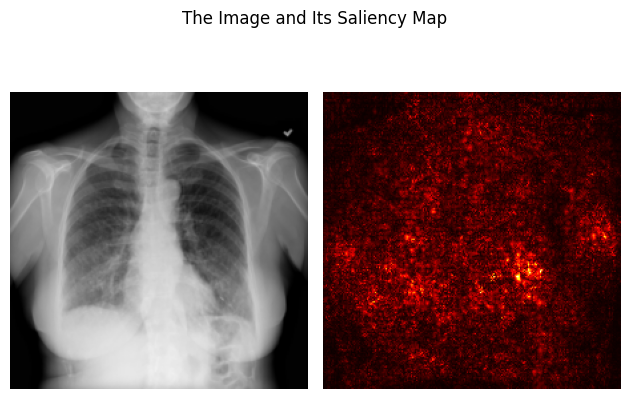

In [28]:
print_saliency(0)

In [29]:
print(labels[0])

tensor(0, device='cuda:0')


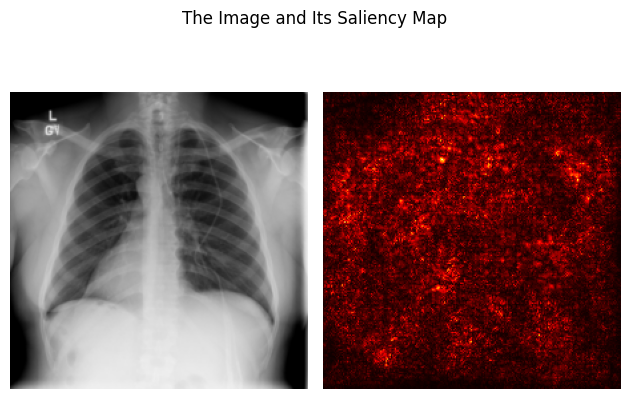

In [30]:
print_saliency(50)

In [31]:
print(labels[50])

tensor(0, device='cuda:0')


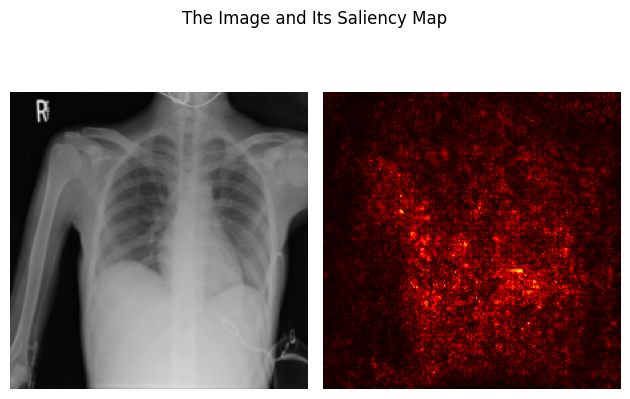

In [32]:
print_saliency(78)

In [33]:
print(labels[78])

tensor(0, device='cuda:0')


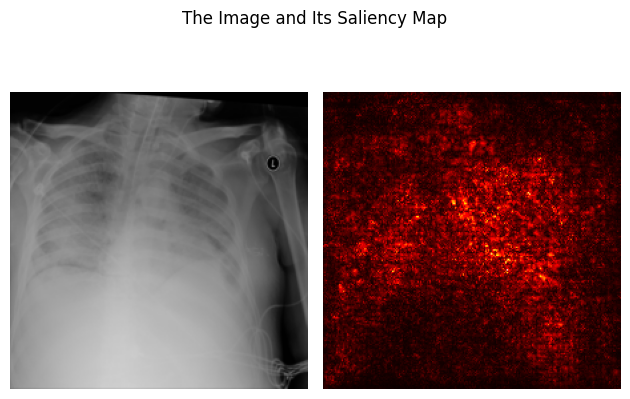

In [34]:
print_saliency(20)

In [35]:
print(labels[20])

tensor(1, device='cuda:0')


In [36]:
torch.save(model.state_dict(), "Transfer_Learning_Resnet.pt")

# Confusion Matrix
#

In [37]:
model.load_state_dict(torch.load('Transfer_Learning_Resnet.pt'))

<All keys matched successfully>

In [38]:
model.eval()

correct = 0
total = 0
val_preds = torch.tensor([]).to(device)
val_labels = torch.tensor([]).to(device)
for images, labels in tqdm(val_loader):
    images = images.to(device)
    labels = labels.to(device)
    predictions = model(images)
    _, predicted = torch.max(predictions, 1)
    val_preds = torch.cat((val_preds, predicted),dim=0)
    val_labels = torch.cat((val_labels, labels),dim=0)
    total += labels.size(0)
    correct += (labels == predicted).sum()
print(f'Val_Acc: {100*correct/total}') # Acc may be messed up because train split may be diff this time around

100%|██████████| 24/24 [01:06<00:00,  2.75s/it]

Val_Acc: 85.31260681152344


In [39]:
print(val_preds.shape, val_labels.shape)

torch.Size([3023]) torch.Size([3023])


In [40]:
train_preds.shape

torch.Size([408060])

In [44]:
preds = torch.cat((train_preds, val_preds), dim = 0)
labels = torch.cat((torch.from_numpy(train_labels[:, 1].astype(np.int64)).to(device), val_labels), dim = 0)
print(preds.shape, labels.shape)

torch.Size([411083]) torch.Size([30227])


In [45]:
from sklearn.metrics import confusion_matrix

In [55]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(cm,channels, title='Confusion matrix', cmap=plt.cm.Blues,filename="confusion_matrix.png"):
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(channels))
    plt.xticks(tick_marks, channels, rotation=45,ha='right')
    plt.yticks(tick_marks, channels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig("data/"+filename)
    plt.show()


In [47]:
labels.cpu()

tensor([0., 0., 0.,  ..., 1., 0., 0.])

In [56]:
cm = confusion_matrix(val_labels.cpu(), val_preds.cpu())
print(type(cm))
cm

<class 'numpy.ndarray'>


array([[1895,  187],
       [ 257,  684]])

In [50]:
cm/sum(cm)

array([[0.88057621, 0.21469575],
       [0.11942379, 0.78530425]])

In [51]:
classes = np.array(["Negative", "Positive"])

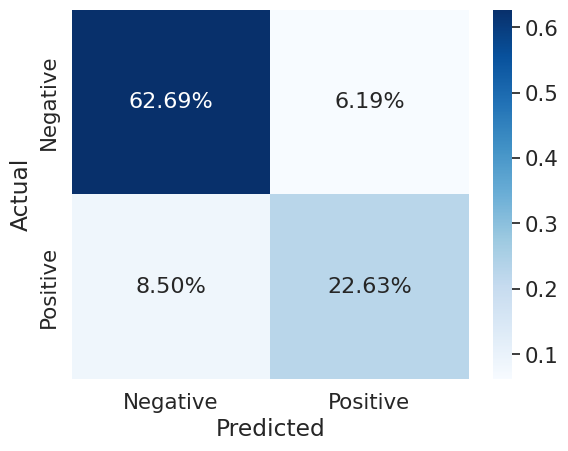

In [57]:
df_cm = pd.DataFrame(cm/cm.sum(), classes, classes)
# plt.figure(figsize=(10,7))
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True, fmt='.2%', annot_kws={"size": 16}, cmap='Blues') # font size
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()